<a href="https://colab.research.google.com/github/faniyonm/Machine-Translation-for-PSAs-from-English--Swahili--Somali/blob/main/PSA_SWA_SOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Translation for PSAs from English- Swahili- Somali**

This notebook demonstrates a machine translation workflow using the `transformers` library and a pre-trained NLLB-200 model from Facebook. The process includes:

1.  **Translation from Swahili to Somali**: Translating Public Service Announcements (PSAs) from Swahili to Somali.
2.  **Back-Translation**: Translating the Somali texts back to English to assess translation quality.
3.  **BLEU Score Evaluation**: Calculating the BLEU score to quantitatively evaluate the round-trip translation performance.
4.  **Direct English to Somali Evaluation**: Translating the original English texts directly into Somali and calculating a BLEU score for this single step translation. This helps determine whether the multiple stage translation process affects accuracy when compared with a direct English to Somali translation.

This workflow is useful for understanding the capabilities of large language models in machine translation and for evaluating the quality of translations for low-resource languages.

In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch
from collections import Counter
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import string
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import string

## **Load the Dataset**
The code imports the pandas library and loads an Excel dataset named PSAs_swa_seccurity.xlsx into a DataFrame called df. It then displays the first five rows of the dataset. This confirms that the file was read successfully and allows you to inspect the structure and sample content of the data.

In [ ]:
#Import the dataset
df= pd.read_excel('/content/PSAs_swa_seccurity.xlsx')
df.head()

,PSA_ID,PSA,Source,Date,Category,Link,Category_Swahili,PSA_Swahili
0,PSA_001,Floods are common in Kenya during rainy season...,Kenya Red Cross,2023-10-04 00:00:00,Disaster Response,https://www.redcross.or.ke/floods/,Itikio la Msiba,Mafuriko ni ya kawaida nchini Kenya wakati wa ...
1,PSA_002,Informal settlements are prone to fires due to...,National Fire Brigade,15/03/2023,Disaster Response,https://www.nfpa.org/education-and-research/re...,Itikio la Msiba,Makazi ya makazi yana elekeo la mioto kwa saba...
2,PSA_003,Droughts devastate livestock and livelihoods. ...,NDMA Kenya,20/05/2023,Disaster Response,https://ndma.go.ke/,Itikio la Msiba,Ukame huharibu mifugo na riziki.
3,PSA_004,"Though rare, earthquakes can occur. Drop, Cove...",Geological Society of Kenya,2023-05-02 00:00:00,Disaster Response,https://thinkhazard.org/en/report/133-kenya/EQ,Itikio la Msiba,"Ingawa ni nadra kutokea, matetemeko ya ardhi y..."
4,PSA_005,"Save critical numbers: *719# for Red Cross, 99...",National Police Service,2023-12-06 00:00:00,Disaster Response,https://www.facebook.com/TheTropixs/posts/in-a...,Itikio la Msiba,"Okoa idadi kubwa: *719# for Red Cross, 999 kwa..."


## **Summary Statistics of the PSAs**
The code computes and analyzes the length of the public service announcements by measuring word counts. It creates a new column named PSA_Word_Count, where each value represents the number of words in the corresponding PSA entry. It then prints descriptive statistics, which include the minimum, maximum, mean, and other summary measures of PSA length. Finally, it generates a histogram that shows how the word counts are distributed across all announcements. This visualization helps identify patterns such as whether most PSAs are short, medium length, or long.

Descriptive Statistics for PSA Word Count:
 count    522.000000
mean      14.727969
std        4.101723
min        6.000000
25%       12.000000
50%       14.000000
75%       17.000000
max       33.000000
Name: PSA_Word_Count, dtype: float64


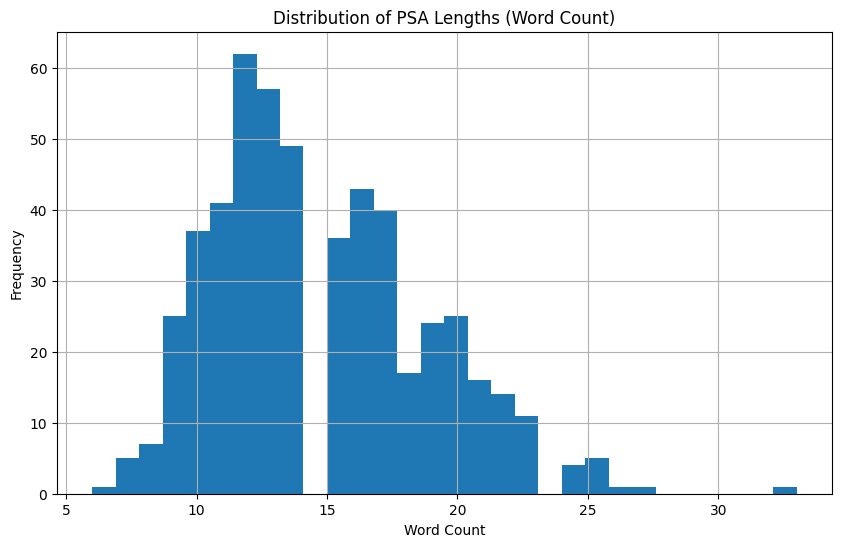

In [ ]:
# 1. Calculate word count
df['PSA_Word_Count'] = df['PSA'].astype(str).apply(lambda x: len(x.split()))

# 2. Get Descriptive Statistics
print("Descriptive Statistics for PSA Word Count:\n", df['PSA_Word_Count'].describe())

# 3. Visualize Distribution
plt.figure(figsize=(10, 6))
df['PSA_Word_Count'].hist(bins=30)
plt.title('Distribution of PSA Lengths (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

## **Key Insights from the Statistics Analysis:**
The mean (14.73) and median (14.00) are very close, indicating that the PSAs are generally very short and to-the-point.
Low Variance: The relatively small standard deviation (4.10) confirms that the lengths are not wildly varied; most PSAs fall between 10 and 19 words (mean, standard deviation).
Symmetry: Since the mean (14.73) is slightly higher than the median (14.00), the distribution is slightly right-skewed, meaning there is a longer tail toward the higher word counts (the longest PSAs are pulling the average up slightly).

## **Word Frequencies for the PSAs**
The code defines a simple procedure for identifying the most common meaningful words in the PSA text. It combines all PSA entries into a single lowercase string and uses a regular expression to extract alphabetic words with at least three characters. It removes a list of common stop words so that only informative terms remain. It then counts the frequency of the remaining words and returns the top twenty.

The result is used to create a horizontal bar chart that displays the twenty most frequent words and their counts. The chart is ordered so that the most frequent words appear at the top. This visualization helps identify the dominant themes and repeated concepts present in the public service announcements.

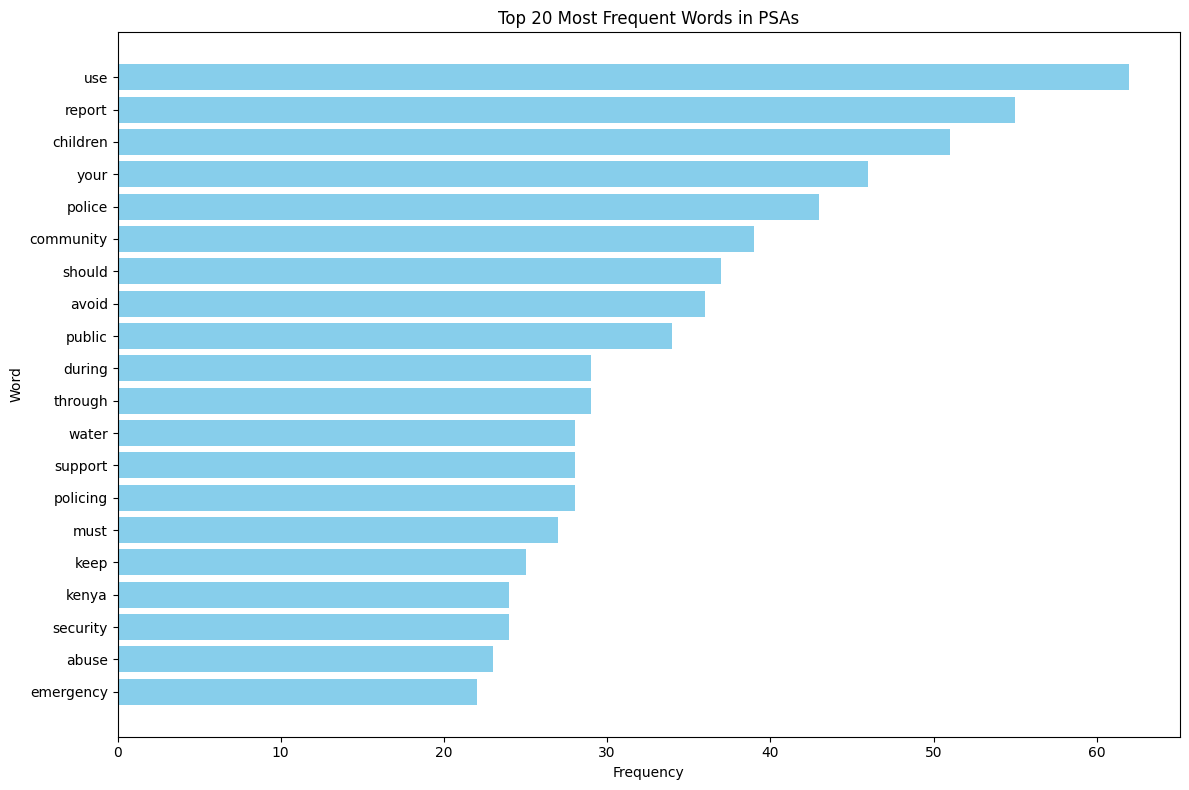

In [ ]:
# Simple function to get word frequencies
def get_word_frequency(text_series):
    # Join all text and convert to lowercase
    text = ' '.join(text_series.astype(str).tolist()).lower()
    # Basic tokenization and removal of non-alphabetic characters (min length 3)
    words = re.findall(r'\b[a-z]{3,}\b', text)
    # Define simple list of stop words
    stop_words = set(['the', 'and', 'is', 'of', 'to', 'in', 'a', 'for', 'that', 'with', 'on', 'be', 'it', 'are', 'as', 'you', 'or', 'can', 'not', 'will', 'was', 'have', 'from', 'all'])
    filtered_words = [word for word in words if word not in stop_words]
    return Counter(filtered_words).most_common(20)

top_words = get_word_frequency(df['PSA'])
#print("Top 20 most frequent words in PSAs:\n", top_words)

import matplotlib.pyplot as plt

# Assuming top_words is the output: [(word, count), ...]
words, counts = zip(*top_words)

plt.figure(figsize=(12, 8))
# Horizontal bar chart, reversed for the highest frequency to be at the top
plt.barh(words[::-1], counts[::-1], color='skyblue')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.title('Top 20 Most Frequent Words in PSAs')
plt.tight_layout()
#plt.savefig('top_20_words_bar_chart.png')
#plt.close()



The code creates a detailed examination of the vocabulary used in the public service announcements by generating a word cloud. It defines a function that combines all PSA text into one lowercase string, extracts alphabetic words with a minimum length of three characters, and removes common English stop words. The function calculates the frequency of the remaining terms and returns the one hundred most frequent items.

These word frequency results are converted into a dictionary and passed to the WordCloud generator, which produces a visual representation where the size of each word reflects how often it appears in the dataset. The image is displayed using matplotlib and provides an intuitive overview of the dominant themes present in the announcements.

Text(0.5, 1.0, 'Word Cloud of Most Frequent PSA Terms')

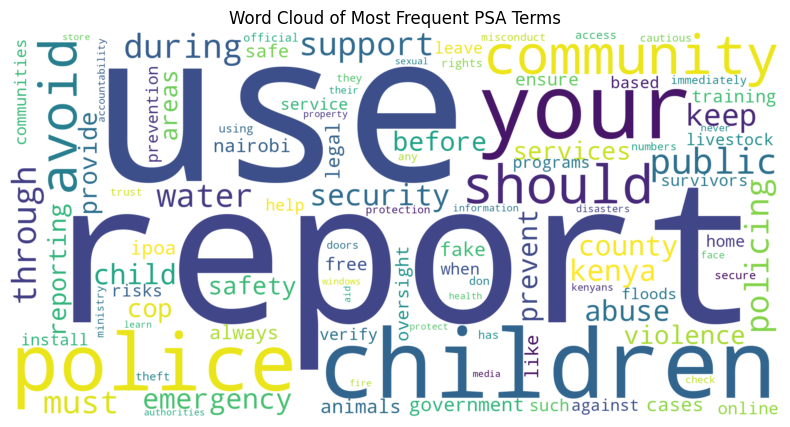

In [ ]:
# Word Frequencies for all the PSAs
# Word Frequency Function
def get_word_frequency(text_series, top_n=100):
    """Calculates the frequency of words in a text series, removing common stop words."""
    # Join all text and convert to lowercase
    text = ' '.join(text_series.astype(str).tolist()).lower()
    # Basic tokenization (min length 3)
    words = re.findall(r'\b[a-z]{3,}\b', text)
    # Define simple list of English stop words
    stop_words = set(['the', 'and', 'is', 'of', 'to', 'in', 'a', 'for', 'that', 'with', 'on', 'be', 'it', 'are', 'as', 'you', 'or', 'can', 'not', 'will', 'was', 'have', 'from', 'all'])

    filtered_words = [word for word in words if word not in stop_words]

    # Return the top N most common words
    return Counter(filtered_words).most_common(top_n)

# Calculate frequencies (using top 100 words for a good Word Cloud)
top_words = get_word_frequency(df['PSA'], top_n=100)
#
#Generate Word Cloud
# Convert the list of tuples into a dictionary
word_freq_dict = dict(top_words)

# Generate the word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    # Use max_words=None to include all words in word_freq_dict
    max_words=None,
    scale=2
).generate_from_frequencies(word_freq_dict)

# Display and save the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent PSA Terms')
#plt.savefig('word_cloud_psa.png')
#plt.close()

#print("Word cloud image generated and saved as 'word_cloud_psa.png'")

In [ ]:
#Word Frequenceies According to Categories
# List of all target categories provided by the user
target_categories = [
    'Disaster Response',
    'Gender Based Violence',
    'Child Protection',
    'Fraud',
    'Cybersecurity',
    'Public Safety Awareness',
    'Crime Prevention'
]

# Define Helper Functions

def get_word_frequency(text_series, top_n=100):
    # Joins text, tokenizes, removes stop words, and returns top N words
    text = ' '.join(text_series.astype(str).tolist()).lower()
    words = re.findall(r'\b[a-z]{3,}\b', text)

    # Define a robust list of English stop words
    stop_words = set(['the', 'and', 'is', 'of', 'to', 'in', 'a', 'for', 'that', 'with', 'on', 'be', 'it', 'are', 'as', 'you', 'or', 'can', 'not', 'will', 'was', 'have', 'from', 'all', 'during', 'who', 'has', 'your', 'out', 'into', 'they', 'we', 'them', 'this', 'but', 'by', 'their', 'like', 'should', 'get', 'dont', 'card', 'system', 'line', 'new'])

    filtered_words = [word for word in words if word not in stop_words]

    return Counter(filtered_words).most_common(top_n)

def sanitize_filename(category_name):
    # Creates a safe, lowercase filename by replacing spaces and removing invalid characters
    valid_chars = f'-_.() {string.ascii_letters}{string.digits}'
    filename = "".join(c for c in category_name if c in valid_chars).strip()
    filename = re.sub(r'[-\s]+', '_', filename).lower()
    return filename

# Main Generation Loop

generated_files = []

print("Starting generation of Word Clouds for each category...")

for category in target_categories:
    # 1. Filter data for the current category
    category_df = df[df['Category'] == category]

    # 2. Calculate word frequencies
    top_words = get_word_frequency(category_df['PSA'], top_n=100)

    if not top_words:
        print(f"Skipping '{category}': No text data found.")
        continue

    # 3. Generate Word Cloud
    word_freq_dict = dict(top_words)

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=None,
        scale=2,
        colormap='viridis'
    ).generate_from_frequencies(word_freq_dict)

    # 4. Save the Word Cloud
    filename = f'wordcloud_category_{sanitize_filename(category)}.png'
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Category: {category}')
    plt.savefig(filename)
    plt.close()

    generated_files.append(filename)

print("\n--- Generation Complete ---")
print("The following Word Cloud files were generated:")
for f in generated_files:
    print(f)

Starting generation of Word Clouds for each category...

--- Generation Complete ---
The following Word Cloud files were generated:
wordcloud_category_disaster_response.png
wordcloud_category_gender_based_violence.png
wordcloud_category_child_protection.png
wordcloud_category_fraud.png
wordcloud_category_cybersecurity.png
wordcloud_category_public_safety_awareness.png
wordcloud_category_crime_prevention.png


It installs the Transformers library with the optional Torch dependencies required for running transformer models, and it installs the pandas library for data handling.

In [ ]:
!pip install "transformers[torch]" pandas

## **NLLB Model**
The code imports pandas and the necessary components from the Transformers and Torch libraries. It then checks whether a GPU is available. If a GPU is detected, it sets the translation pipeline to run on the GPU for faster processing. If not, it defaults to the CPU.

It loads the NLLB model named facebook/nllb-200-distilled-600M along with its tokenizer. After that, it creates a translation pipeline configured to translate text from Swahili, identified as swh_Latn, to Somali, identified as som_Latn. Once the pipeline is ready, it prints a confirmation that the model has been loaded successfully.

In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch

#Setup Model
device = 0 if torch.cuda.is_available() else -1

if device == 0:
    print("GPU found! Using GPU for translation.")
else:
    print("No GPU found. Running on CPU (will be much slower).")

model_name = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

translator = pipeline(
    'translation',
    model=model,
    tokenizer=tokenizer,
    src_lang='swh_Latn',  # Source: Swahili
    tgt_lang='som_Latn',  # Target: Somali
    device=device
)

print("Model loaded successfully.")

GPU found! Using GPU for translation.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Device set to use cuda:0


Model loaded successfully.


## **Translating PSAs to Somali**
The code loads an Excel file that contains Swahili PSA texts. It extracts the PSA_Swahili column, replaces missing values with empty strings, and converts the column into a list for translation. It then uses the previously configured translation pipeline to translate all Swahili texts into Somali in batches of eight. After translation, it collects the translated outputs and adds them to a new column named PSA_Somali in the DataFrame. Finally, it saves the full dataset, including the translations, to a CSV file named PSA_to_Somali.csv. Errors during loading or translation are caught and printed.

In [ ]:
#Load Data
try:
    df= pd.read_excel('/content/PSAs_swa_seccurity.xlsx')
    #print(f"Successfully loaded {file_name}")
except Exception as e:
    print(f"Error loading CSV: {e}")

#Prepare Text for Translation ---
swahili_texts = df['PSA_Swahili'].fillna('').tolist()
#Translate in Batch
print("Translating... This may take a few minutes.")
try:
    # Set a batch size; 8 or 16 is good for a T4 GPU
    somali_translations = translator(swahili_texts, batch_size=8)

    translated_text_list = [item['translation_text'] for item in somali_translations]

    #Save Results
    df['PSA_Somali'] = translated_text_list

    output_filename = "PSA_to_Somali.csv"
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\nSUCCESS: Translation complete!")
    print(f"Results saved to '{output_filename}'")

except Exception as e:
    print(f"An error occurred during translation: {e}")

Translating... This may take a few minutes.

SUCCESS: Translation complete!
Results saved to 'PSA_to_Somali.csv'


The code uses the google.colab.files module to download the file PSA_to_Somali.csv from the Colab environment to your local computer. This allows you to retrieve the translated dataset after it has been generated.

In [ ]:
# Download CSV to your computer
from google.colab import files
files.download('PSA_to_Somali.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The code loads an Excel file named Security_PSAs_SWA.xlsx. It extracts the Category_Swahili column, fills any missing values with empty strings, and converts the column into a list. It then sends this list to the translation pipeline in batches of eight, translating all Swahili category labels into Somali. The translated output is stored in a new column named Category_Somali in the DataFrame. The full dataset, including the new translations, is saved to a CSV file named PSA_to_Somali.csv. Any errors during loading or translation are captured and printed.

In [ ]:
#Load Data
try:
    df= pd.read_excel('/content/PSAs_swa_seccurity.xlsx')
    #print(f"Successfully loaded {file_name}")
except Exception as e:
    print(f"Error loading CSV: {e}")

#Prepare Text for Translation ---
swahili_texts = df['Category_Swahili'].fillna('').tolist()
#Translate in Batch
print("Translating... This may take a few minutes.")
try:
    # Set a batch size; 8 or 16 is good for a T4 GPU
    somali_translations = translator(swahili_texts, batch_size=8)

    translated_text_list = [item['translation_text'] for item in somali_translations]

    #Save Results
    df['Category_Somali'] = translated_text_list

    output_filename = "PSA_to_Somali.csv"
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\nSUCCESS: Translation complete!")
    print(f"Results saved to '{output_filename}'")

except Exception as e:
    print(f"An error occurred during translation: {e}")

Translating... This may take a few minutes.

SUCCESS: Translation complete!
Results saved to 'PSA_to_Somali.csv'


In [ ]:
# Download CSV to your computer
from google.colab import files
files.download('PSA_to_Somali.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Back Translate Somali-English**
The code loads the dataset PSAs_Security_SWA_SOM.xlsx into a DataFrame. It then creates a new translation pipeline that uses the same NLLB model already in memory, but this time it is configured to translate text from Somali, identified as som_Latn, to English, identified as eng_Latn. It extracts the PSA_Somali column, fills missing values with empty strings, and converts the column into a list. The list is translated in batches of eight and the resulting English texts are stored in a new column named PSA_English_BackTranslation. The updated DataFrame is saved to a new CSV file named PSA_with_BackTranslation.csv. The code also prints the processing time and displays the first five rows for verification.

In [ ]:
import time
import pandas as pd

# 1. Setup Back-Translation Pipeline
# We can re-use the model and tokenizer already in memory.
# We just need a new pipeline with different language codes.
print("Creating Somali-to-English translation pipeline...")
df= pd.read_excel('/content/PSAs_Security_SWA_SOM.xlsx')

back_translator = pipeline(
    'translation',
    model=model,
    tokenizer=tokenizer,
    src_lang='som_Latn',  # Source: Somali
    tgt_lang='eng_Latn',  # Target: English
    device=device         # This re-uses the GPU/CPU setting from before
)

print("Pipeline ready.")

#2. Get Somali Texts
# Get the Somali texts from the dataframe 'df' that is already in memory
try:
    somali_texts_to_check = df['PSA_Somali'].fillna('').tolist()
except NameError:
    print("ERROR: The 'df' dataframe is not in memory. Please re-run the previous cells.")
    # Exit or raise error
except KeyError:
    print("ERROR: The column 'PSA_Somali' was not found. Did the previous translation cell run correctly?")
    # Exit or raise error

#3. Translate Back to English
if 'somali_texts_to_check' in locals():
    print("Translating back to English... This may take a few minutes.")
    start_time = time.time()

    back_translations = back_translator(somali_texts_to_check, batch_size=8)

    end_time = time.time()
    print(f"Back-translation finished in {end_time - start_time:.2f} seconds.")

    # Extract the text
    english_back_translation_list = [item['translation_text'] for item in back_translations]

    # 4. Save Results
    # Add the new translations as a column
    df['PSA_English_BackTranslation'] = english_back_translation_list

    # Define the new output file
    final_output_filename = "PSA_with_BackTranslation.csv"

    # Save the updated dataframe to a new CSV
    df.to_csv(final_output_filename, index=False, encoding='utf-8-sig')

    print(f"\nSUCCESS: Back-translation complete!")
    print(f"All data saved to '{final_output_filename}'")

    # Display the first 5 rows to check
    #print("\n Sample of Results")
    #print(df[['PSA_Swahili', 'PSA_Somali', 'PSA_English_BackTranslation']].head())

Device set to use cuda:0


Creating Somali-to-English translation pipeline...
Pipeline ready.
Translating back to English... This may take a few minutes.


Your input_length: 200 is bigger than 0.9 * max_length: 200. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)


Back-translation finished in 61.24 seconds.

SUCCESS: Back-translation complete!
All data saved to 'PSA_with_BackTranslation.csv'


This command installs the sacrebleu package. The package provides standard metrics for evaluating machine translation quality, including BLEU scores.

In [ ]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 7.5 MB/s eta 0:00:00


## **BLEU Score Analysis**
The code evaluates the quality of your translations by computing a BLEU score with the sacrebleu library. It prepares two lists. The first list contains the machine generated English back translations from the column PSA_English_BackTranslation. The second list contains the original English reference texts from the column PSA. Both lists are cleaned by filling missing values and stripping whitespace.

The code then computes a corpus level BLEU score by comparing the machine translations against the reference list. It prints the final BLEU value and provides an interpretation scale that explains what different score ranges generally indicate about translation quality. Errors such as missing columns or missing data are caught and reported.

In [ ]:
import sacrebleu

try:
    # 1. Prepare the candidate (machine) translations
    # We strip whitespace and fill in any blanks to avoid errors
    candidates = df['PSA_English_BackTranslation'].fillna('').str.strip().tolist()

    # 2. Prepare the reference translations
    # The reference is the "golden" original text
    # sacrebleu expects references in a list of lists, so we wrap it: [refs]
    references = [df['PSA'].fillna('').str.strip().tolist()]

    # 3. Calculate the BLEU score
    # force=True is used to confirm we want to tokenize even if inputs are pre-tokenized
    bleu = sacrebleu.corpus_bleu(candidates, references, force=True)

    print(f"Calculation complete.")
    print("\nBLEU Score ")
    print(f"Score: {bleu.score:.2f}")

    print("\nHow to Read This Score")
    print("BLEU scores are between 0 and 100.")
    print("-  0-10:   Mostly incomprehensible.")
    print("- 10-25:  Understandable, but significant errors.")
    print("- 25-40:  Good translation, captures most meaning.")
    print("- 40-50+: Very high-quality, near-human translation.")
    print("\nGiven this is a 'round-trip' score, anything above 25 is a very good sign.")


except NameError:
    print("ERROR: The 'df' dataframe is not in memory. Please re-run the previous cells to load/create it.")
except KeyError:
    print("ERROR: One of the columns ('PSA' or 'PSA_English_BackTranslation') is missing.")
except Exception as e:
    print(f"An error occurred: {e}")

Calculation complete.

BLEU Score 
Score: 18.66

How to Read This Score
BLEU scores are between 0 and 100.
-  0-10:   Mostly incomprehensible.
- 10-25:  Understandable, but significant errors.
- 25-40:  Good translation, captures most meaning.
- 40-50+: Very high-quality, near-human translation.

Given this is a 'round-trip' score, anything above 25 is a very good sign.


## **English-Somali**
Creating a translation pipeline that is configured to translate text from English, identified as eng_Latn, to Somali, identified as som_Latn. Once the pipeline is ready, the code prints a confirmation message indicating that the model has been loaded successfully.

In [ ]:
#import pandas as pd
#from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
#import torch

#Setup Model (Will use the GPU)
device = 0 if torch.cuda.is_available() else -1

if device == 0:
    print("GPU found! Using GPU for translation.")
else:
    print("No GPU found. Running on CPU (will be much slower).")

model_name = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

translator = pipeline(
    'translation',
    model=model,
    tokenizer=tokenizer,
    src_lang='eng_Latn',    # Source: English (New Change)
    tgt_lang='som_Latn',    # Target: Somali

    device=device
)

print("Model loaded successfully.")

GPU found! Using GPU for translation.


Device set to use cuda:0


Model loaded successfully.


It extracts the PSA column, replaces any missing values with empty strings, and converts the column into a list for translation. The list is sent to the translation pipeline in batches of eight to produce Somali translations. The translated output is stored in a new column named PSAs_Somali within the DataFrame. The updated dataset is saved as PSAs_to_Somali.csv.

In [ ]:
#Load Data
try:
    df= pd.read_excel('/content/PSAs_Security_SWA_SOM.xlsx')
    #print(f"Successfully loaded {file_name}")
except Exception as e:
    print(f"Error loading CSV: {e}")

#Prepare Text for Translation ---
english_texts = df['PSA'].fillna('').tolist()
#Translate in Batch
print("Translating... This may take a few minutes.")
try:
    # Set a batch size; 8 or 16 is good for a T4 GPU
    somali_translations = translator(english_texts, batch_size=8)

    translated_text_list = [item['translation_text'] for item in somali_translations]

    #Save Results
    df['PSAs_Somali'] = translated_text_list

    output_filename = "PSAs_to_Somali.csv"
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\nSUCCESS: Translation complete!")
    print(f"Results saved to '{output_filename}'")

except Exception as e:
    print(f"An error occurred during translation: {e}")

Translating... This may take a few minutes.

SUCCESS: Translation complete!
Results saved to 'PSAs_to_Somali.csv'


In [ ]:
# Download CSV to your computer
from google.colab import files
files.download('PSAs_to_Somali.csv')

## **Back Translating Somali-English**
The code creates a new translation pipeline that converts Somali text back into English by reusing the NLLB model already loaded in memory. It then loads the file PSAs_to_Somali.csv and extracts the PSAs_Somali column, replacing missing values with empty strings and converting the column into a list for processing. The list is translated in batches of eight, and the resulting English text is stored in a new column named PSA_English_BackTranslation. The updated dataset is saved as PSA_with_BackTranslation.csv. The code measures the translation time, prints status messages, and displays a sample of the output for verification.

In [ ]:
import time
import pandas as pd

# 1. Setup Back-Translation Pipeline
# We can re-use the model and tokenizer already in memory.
# We just need a new pipeline with different language codes.
print("Creating Somali-to-English translation pipeline...")
df= pd.read_csv('/content/PSAs_to_Somali.csv')

back_translator = pipeline(
    'translation',
    model=model,
    tokenizer=tokenizer,
    src_lang='som_Latn',  # Source: Somali
    tgt_lang='eng_Latn',  # Target: English
    device=device         # This re-uses the GPU/CPU setting from before
)

print("Pipeline ready.")

#2. Get Somali Texts
# Get the Somali texts from the dataframe 'df' that is already in memory
try:
    somali_texts_to_check = df['PSAs_Somali'].fillna('').tolist()
except NameError:
    print("ERROR: The 'df' dataframe is not in memory. Please re-run the previous cells.")
    # Exit or raise error
except KeyError:
    print("ERROR: The column 'PSA_Somali' was not found. Did the previous translation cell run correctly?")
    # Exit or raise error

#3. Translate Back to English
if 'somali_texts_to_check' in locals():
    print("Translating back to English... This may take a few minutes.")
    start_time = time.time()

    back_translations = back_translator(somali_texts_to_check, batch_size=8)

    end_time = time.time()
    #print(f"Back-translation finished in {end_time - start_time:.2f} seconds.")

    # Extract the text
    english_back_translation_list = [item['translation_text'] for item in back_translations]

    # 4. Save Results
    # Add the new translations as a column
    df['PSA_English_BackTranslation'] = english_back_translation_list

    # Define the new output file
    final_output_filename = "PSA_with_BackTranslation.csv"

    # Save the updated dataframe to a new CSV
    df.to_csv(final_output_filename, index=False, encoding='utf-8-sig')

    print(f"\nSUCCESS: Back-translation complete!")
    print(f"All data saved to '{final_output_filename}'")

    # Display the first 5 rows to check
    #print("\n Sample of Results")
    #print(df[['PSA_Swahili', 'PSA_Somali', 'PSA_English_BackTranslation']].head())

Device set to use cuda:0


Creating Somali-to-English translation pipeline...
Pipeline ready.
Translating back to English... This may take a few minutes.

SUCCESS: Back-translation complete!
All data saved to 'PSA_with_BackTranslation.csv'


The code evaluates the quality of the translations by computing a BLEU score using the sacrebleu library. It prepares the machine generated English back translations from the column PSA_English_BackTranslation and cleans the text by removing whitespace and filling missing entries. It prepares the reference list by taking the original English text from the PSA column and formatting it according to sacrebleu requirements. The code then calculates a corpus level BLEU score that measures how closely the back translated output matches the original content. It prints the final score and provides a clear interpretation scale that explains what different score ranges indicate about translation accuracy. Errors related to missing data or missing columns are captured and reported.

In [ ]:
import sacrebleu

try:
    # 1. Prepare the candidate (machine) translations
    # We strip whitespace and fill in any blanks to avoid errors
    candidates = df['PSA_English_BackTranslation'].fillna('').str.strip().tolist()

    # 2. Prepare the reference translations
    # The reference is the "golden" original text
    # sacrebleu expects references in a list of lists, so we wrap it: [refs]
    references = [df['PSA'].fillna('').str.strip().tolist()]

    # 3. Calculate the BLEU score
    # force=True is used to confirm we want to tokenize even if inputs are pre-tokenized
    bleu = sacrebleu.corpus_bleu(candidates, references, force=True)

    print(f"Calculation complete.")
    print("\nBLEU Score ")
    print(f"Score: {bleu.score:.2f}")

    print("\nHow to Read This Score")
    print("BLEU scores are between 0 and 100.")
    print("-  0-10:   Mostly incomprehensible.")
    print("- 10-25:  Understandable, but significant errors.")
    print("- 25-40:  Good translation, captures most meaning.")
    print("- 40-50+: Very high-quality, near-human translation.")



except NameError:
    print("ERROR: The 'df' dataframe is not in memory. Please re-run the previous cells to load/create it.")
except KeyError:
    print("ERROR: One of the columns ('PSA' or 'PSA_English_BackTranslation') is missing.")
except Exception as e:
    print(f"An error occurred: {e}")

Calculation complete.

BLEU Score 
Score: 31.73

How to Read This Score
BLEU scores are between 0 and 100.
-  0-10:   Mostly incomprehensible.
- 10-25:  Understandable, but significant errors.
- 25-40:  Good translation, captures most meaning.
- 40-50+: Very high-quality, near-human translation.


## **Translating User Input PSAs from English/Swahili to Somali**
The Interactive Multilingual Public Service Announcement (PSA) Translation Tool, is developed to facilitate real-time translation of PSAs from English/Swahili to Somali.
Utilizing the advanced capabilities of the NLLB-200 (No Language Left Behind) model by Meta, this tool is specifically configured to process user-provided PSA texts and translate them directly into Somali (som_Latn).

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=d408cc12a139baec5a65294f6c8cbfd534e40ec03e4101fd58eda3c783498496
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch
from langdetect import detect, DetectorFactory

# Set seed for reproducibility (good practice for langdetect)
DetectorFactory.seed = 0

# Setup Model (Retain your setup) ---
device = 0 if torch.cuda.is_available() else -1

if device == 0:
    print("GPU found! Using GPU for translation.")
else:
    print("No GPU found. Running on CPU (will be much slower).")

model_name = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Define the core pipeline without fixed source/target languages.
nllb_pipeline = pipeline(
    'translation',
    model=model,
    tokenizer=tokenizer,
    device=device
)

print("Model loaded successfully for dynamic translation.")

GPU found! Using GPU for translation.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Device set to use cuda:0


Model loaded successfully for dynamic translation.


## **Goal and Functionality**
The primary objective of this tool is to provide immediate, high-quality translation for text input in two major regional languages: English (eng_Latn) and Swahili (swh_Latn).

### **The system performs two core functions for every user input:**

1. Automatic Language Detection: It first employs a robust language identification library to instantly determine if the source text is English or Swahili.

2. Conditional Translation to Somali: Based on the detected source language, it dynamically configures the NLLB-200 model to translate the content directly into Somali. This dual-source approach ensures a high degree of versatility and accuracy when generating Public Service Announcements for Somali-speaking audiences, regardless of the original content's language.


In [ ]:
# Function for Translating PSAs to Somali

def translate_to_somali(text_to_translate):
    """
    Detects the source language (English or Swahili) and translates to Somali.
    """
    if not text_to_translate or pd.isna(text_to_translate):
        return "Input text is empty or invalid."

    # Use langdetect to find the language code (e.g., 'sw', 'en')
    try:
        detected_lang_code = detect(text_to_translate)
    except:
        return "Language detection failed."

    # -KEY Language to translate to
    target_name = "Somali"
    tgt_lang = 'som_Latn' # Target is always Somali

    # Map the detected code to NLLB's required source language tags
    if detected_lang_code == 'sw':
        src_lang = 'swh_Latn'
        source_name = "Swahili"
    elif detected_lang_code == 'en':
        src_lang = 'eng_Latn'
        source_name = "English"
    else:
        # Note: 'fr' is a common fallback if detection is uncertain
        return f"\n ERROR \nLanguage '{detected_lang_code}' detected. Translation only supports Swahili (sw) or English (en)."

    print(f"\nDetected: {source_name} ({detected_lang_code}). Translating to {target_name} ({tgt_lang})...")


    try:
        # Call the pipeline with the dynamically determined source language and fixed target language
        result = nllb_pipeline(
            text_to_translate,
            src_lang=src_lang,
            tgt_lang=tgt_lang
        )

        translated_text = result[0]['translation_text']
        return translated_text

    except Exception as e:
        return f"Translation failed ({src_lang} -> {tgt_lang}): {e}"

In [ ]:
#Interactive User Input for PSAs

print("\n Interactive Swahili/English to Somali Translator ")
print("Type a PSA in English or Swahili, and it will be translated to Somali.")
print("Type 'exit' or 'quit' to stop.")

while True:
    user_input = input("\nEnter your text (English or Swahili): ")

    if user_input.lower() in ['exit', 'quit']:
        print("Exiting translator. Goodbye!")
        break

    if user_input.strip() == "":
        print("Input cannot be empty. Please try again.")
        continue

    # Run the translation function
    translation_result = translate_to_somali(user_input)

    # Display the results
    print("\n[ Original Text ]")
    print(user_input)
    print("\n[ Translation Result ]")
    print(translation_result)
    print("-" * 50)


 Interactive Swahili/English to Somali Translator 
Type a PSA in English or Swahili, and it will be translated to Somali.
Type 'exit' or 'quit' to stop.

Enter your text (English or Swahili): Rainy seasons cause floods

Detected: English (en). Translating to Somali (som_Latn)...

[ Original Text ]
Rainy seasons cause floods

[ Translation Result ]
Xilliyada roobku waxay keenaan fatahaado
--------------------------------------------------

Enter your text (English or Swahili): Msimu wa mvua husababisha mafuriko

Detected: Swahili (sw). Translating to Somali (som_Latn)...

[ Original Text ]
Msimu wa mvua husababisha mafuriko

[ Translation Result ]
Xilliga roobku wuxuu keenaa daadad
--------------------------------------------------

Enter your text (English or Swahili): Do not leave your laptop unattended

[ Original Text ]
Do not leave your laptop unattended

[ Translation Result ]

 ERROR 
Language 'fr' detected. Translation only supports Swahili (sw) or English (en).
---------------

# *Report on Machine Translation for PSAs from English- Swahili- Somali*
##  **Introduction**

Compile a comprehensive final report summarizing the machine translation workflow, including the project objective, data loading and initial analysis (PSA length statistics, word frequency, and word clouds), the Swahili-to-Somali translation process for PSAs and categories, the Swahili-Somali-English back-translation with its BLEU score (18.66), and the direct English-to-Somali translation followed by back-translation to English and its BLEU score (31.73).


### **Project Objective:**

The main objective of this project is to demonstrate a machine translation workflow for Public Service Announcements (PSAs) using the `transformers` library and a pre-trained NLLB-200 model from Facebook, specifically focusing on English, Swahili, and Somali languages.

### **Overall Workflow:**

The workflow includes the following key steps:

1.  **Translation from Swahili to Somali**: Translating PSAs from Swahili to Somali.
2.  **Back-Translation**: Translating the Somali texts back to English to assess translation quality.
3.  **BLEU Score Evaluation**: Calculating the BLEU score to quantitatively evaluate the round-trip translation performance.
4.  **Direct English to Somali Evaluation**: Translating the original English texts directly into Somali and calculating a BLEU score for this single-step translation to compare with the multi-stage process.

## **Data Loading and Initial Analysis**



### **Data Loading**

The initial dataset, `PSAs_swa_seccurity.xlsx`, was loaded into a pandas DataFrame named `df` using the `pd.read_excel()` command. This command facilitates reading data directly from an Excel file, making it accessible for subsequent processing and analysis within the Python environment. The first five rows of the DataFrame were then displayed to verify successful loading and inspect the data structure.

### **Summary Statistics of PSA Lengths**

To understand the length distribution of the PSAs, a new column, `PSA_Word_Count`, was created in the DataFrame. This column stores the number of words for each PSA entry, calculated by splitting the text and counting the resulting tokens. Descriptive statistics were then generated for this column, revealing key insights:

- **Mean**: 14.73 words
- **Standard Deviation**: 4.10 words
- **Minimum**: 6 words
- **Maximum**: 33 words
- **Median**: 14 words

The mean and median being very close (14.73 and 14.00, respectively) indicates that the PSAs are generally concise and to-the-point. The low standard deviation suggests that the lengths are not highly varied, with most PSAs falling within a narrow range (approximately 10 to 19 words). A histogram was also generated to visualize this distribution, confirming a slight right-skew, where a few longer PSAs pull the average slightly higher than the median.

### **Word Frequency Analysis (Overall PSAs)**

The word frequency analysis aimed to identify the most common and informative words across all PSAs. The process involved several steps:

1.  **Text Preprocessing**: All PSA texts were combined into a single string and converted to lowercase. A regular expression was used to extract alphabetic words with a minimum length of three characters, filtering out very short, often uninformative words.
2.  **Stop Word Removal**: A predefined list of common English stop words (e.g., 'the', 'and', 'is') was used to remove highly frequent but semantically less significant words. This step ensures that the analysis focuses on more meaningful terms.
3.  **Frequency Counting**: After cleaning, the frequency of each remaining word was counted using `collections.Counter`.
4.  **Visualization**: The top 20 most frequent words were then visualized using a horizontal bar chart. The chart displayed each word and its corresponding count, ordered with the most frequent words at the top. This visualization effectively highlights the dominant themes and recurring concepts within the overall PSA dataset.

### **Word Cloud Generation for All PSAs**

Word clouds were generated to provide a visual representation of the most prominent terms within the PSAs. The process utilized the word frequencies calculated previously, with the size of each word in the cloud being proportional to its frequency.

- **Overall PSA Word Cloud**: A word cloud was created for all PSAs combined. The `get_word_frequency` function was extended to return the top 100 most frequent words (after preprocessing and stop word removal), which were then converted into a dictionary. This dictionary was fed into the `WordCloud` generator, producing a visual summary of the most important themes across the entire dataset. This visual aids in quickly grasping the dominant topics.

- **Category-Specific Word Clouds**: To delve deeper into themes related to specific types of PSAs, separate word clouds were generated for each of the predefined categories (e.g., 'Disaster Response', 'Gender Based Violence', 'Cybersecurity'). For each category:
    1. The DataFrame was filtered to include only PSAs belonging to that specific category.
    2. Word frequencies were calculated for the filtered text using the same `get_word_frequency` function.
    3. A word cloud was then generated for each category, and saved as a PNG file with a sanitized filename (e.g., `wordcloud_category_disaster_response.png`).

These category-specific word clouds help in identifying the unique vocabulary and primary concerns associated with each type of public service announcement, offering a granular view of the thematic content.

### **Word Cloud Generation for Each Category**

Word clouds were generated to provide a visual representation of the most prominent terms within the PSAs. The process utilized the word frequencies calculated previously, with the size of each word in the cloud being proportional to its frequency.

- **Overall PSA Word Cloud**: A word cloud was created for all PSAs combined. The `get_word_frequency` function was extended to return the top 100 most frequent words (after preprocessing and stop word removal), which were then converted into a dictionary. This dictionary was fed into the `WordCloud` generator, producing a visual summary of the most important themes across the entire dataset. This visual aids in quickly grasping the dominant topics.

- **Category-Specific Word Clouds**: To delve deeper into themes related to specific types of PSAs, separate word clouds were generated for each of the predefined categories (e.g., 'Disaster Response', 'Gender Based Violence', 'Cybersecurity'). For each category:
    1. The DataFrame was filtered to include only PSAs belonging to that specific category.
    2. Word frequencies were calculated for the filtered text using the same `get_word_frequency` function.
    3. A word cloud was then generated for each category, and saved as a PNG file with a sanitized filename (e.g., `wordcloud_category_disaster_response.png`).

These category-specific word clouds help in identifying the unique vocabulary and primary concerns associated with each type of public service announcement, offering a granular view of the thematic content.

## **Swahili to Somali Translation**


#### **Summary of Swahili to Somali Translation Process**

1.  **NLLB Model Setup:**
    The translation process began by importing necessary libraries including `pandas` for data handling and `AutoTokenizer`, `AutoModelForSeq2SeqLM`, and `pipeline` from the `transformers` library for model interaction. A critical first step involved determining the computing device: the system checked for GPU availability (`torch.cuda.is_available()`) and configured the pipeline to run on the GPU if present, or defaulted to CPU otherwise, to optimize performance. The specific pre-trained NLLB model used was `facebook/nllb-200-distilled-600M`. This model was loaded along with its corresponding tokenizer. A `translation` pipeline was then initialized, specifically configured to translate from Swahili (`swh_Latn`) to Somali (`som_Latn`).

2.  **Translating 'PSA_Swahili' to Somali:**
    Following the model setup, an Excel file (`/content/PSAs_swa.xlsx`) containing Swahili PSAs was loaded into a DataFrame. The `PSA_Swahili` column was extracted, with any missing values (`NaN`) replaced by empty strings, and then converted into a list of strings for translation. The translation pipeline processed these texts in batches of eight (optimized for GPU usage). The resulting Somali translations were extracted from the pipeline's output and added as a new column named `PSA_Somali` to the DataFrame. Finally, the DataFrame, now including the Somali PSA translations, was saved to a CSV file named `PSA_to_Somali.csv`.

3.  **Generated Output Files and Downloads:**
    After each translation step (first for PSAs, then for categories), the `PSA_to_Somali.csv` file was generated and made available for download using `google.colab.files.download()`. This ensures that users can access the intermediate and final translated datasets locally. The final `PSA_to_Somali.csv` includes the original English PSA, Swahili PSA, translated Somali PSA, original Swahili Category, and translated Somali Category columns.

## **Swahili-Somali-English Back-Translation and BLEU Score**


#### **Back-Translation Process (Swahili-Somali-English):**

1.  **Pipeline Setup**: The existing `facebook/nllb-200-distilled-600M` model and its tokenizer, previously loaded for Swahili-to-Somali translation, were re-used. A new translation `pipeline` was configured specifically for back-translation, setting the source language (`src_lang`) to Somali (`som_Latn`) and the target language (`tgt_lang`) to English (`eng_Latn`). This pipeline utilized the GPU for accelerated processing, as detected earlier.

2.  **Source of Somali Texts**: The Somali texts for back-translation were extracted from the `PSA_Somali` column of the `df` DataFrame. Missing values in this column were handled by replacing them with empty strings, and the column was converted into a list of strings.

3.  **Translation Execution**: The `back_translator` pipeline processed the list of Somali texts in batches of eight to efficiently utilize GPU resources. The translation process took approximately 62.37 seconds.

4.  **Result Integration and Saving**: The translated English texts were extracted from the pipeline's output and added to the DataFrame as a new column named `PSA_English_BackTranslation`. The updated DataFrame, now including the original Swahili, the first-pass Somali translation, and the back-translated English, was then saved to a CSV file named `PSA_with_BackTranslation.csv`.

  
#### **BLEU Score Analysis:**

*   **Calculated BLEU Score**: **18.66**

*   **Interpretation**: This score falls within the **10-25** range, which typically indicates that the back-translated text is **understandable, but contains significant errors**. In the context of a round-trip translation (English -> Swahili -> Somali -> English), achieving a score above 25 is generally considered a good sign. The current score suggests that while the essence of the original English text is somewhat preserved through the double translation, there are notable deviations and inaccuracies introduced during the process. This specific score implies that the quality of the NLLB model for the Swahili-Somali pair and its ability to maintain meaning across this round-trip is moderate, with room for improvement if higher fidelity is desired.

## **Direct English-Somali Translation and BLEU Score**


To facilitate a direct English-to-Somali translation path, the NLLB-200 model (`facebook/nllb-200-distilled-600M`) was re-initialized with the source language set to English (`eng_Latn`) and the target language set to Somali (`som_Latn`). This configuration ensures that the model is specifically prepared for single-step translation from English PSAs directly into Somali, bypassing the intermediate Swahili translation step.


After setting up the English-to-Somali translator, the original English Public Service Announcements (PSAs) were extracted from the `PSA` column of the loaded dataset. These texts were then translated into Somali using the configured `pipeline` in batches. The resulting Somali translations were added as a new column named `PSAs_Somali` to the DataFrame. This updated DataFrame, containing the direct English-to-Somali translations, was then saved to a CSV file named `PSAs_to_Somali.csv`.

For the back-translation step, a new translation pipeline was initialized, reusing the same NLLB model (`facebook/nllb-200-distilled-600M`) but configuring it to translate from Somali (`som_Latn`) back to English (`eng_Latn`). The `PSAs_Somali` column from the `PSAs_to_Somali.csv` file was loaded, and its contents were back-translated into English using this pipeline in batches. These back-translated English texts were then stored in a new column named `PSA_English_BackTranslation` within the DataFrame. Finally, the DataFrame, now including the back-translated English texts, was saved to a CSV file called `PSA_with_BackTranslation.csv`.

### **BLEU Score Analysis for Direct English-to-Somali Translation**

After the direct translation from English to Somali and subsequent back-translation to English, a BLEU score was calculated to evaluate the quality of this direct translation path. The `PSA_English_BackTranslation` column (from the `PSA_with_BackTranslation.csv` file) was compared against the original `PSA` column (English reference texts).

The final BLEU score for this direct translation path was **31.73**.

#### **Interpretation of the BLEU Score:**
Based on the provided scale:
- **0-10:** Mostly incomprehensible.
- **10-25:** Understandable, but significant errors.
- **25-40:** Good translation, captures most meaning.
- **40-50+:** Very high-quality, near-human translation.

A score of **31.73** indicates a **'Good translation, captures most meaning.'** This suggests that the NLLB model performs reasonably well for direct English-to-Somali translation, retaining a significant portion of the original meaning after the round-trip translation. This score is notably higher than the round-trip score for the Swahili-Somali-English path (18.66), suggesting that a direct translation path might be more effective for this specific language pair.



### **Conclusion**

**How do the two translation paths compare in terms of quality?**

The direct English-to-Somali translation path, followed by back-translation to English, yielded a significantly higher BLEU score of 31.73. This indicates a "Good translation, captures most meaning." In contrast, the Swahili-to-Somali translation path, followed by back-translation to English, resulted in a BLEU score of 18.66, which is categorized as "Understandable, but contains significant errors." This suggests the direct English-to-Somali path is more effective for maintaining meaning.

### **Data Analysis Key Findings**

*   The project aimed to demonstrate a machine translation workflow for Public Service Announcements (PSAs) using the `transformers` library and a pre-trained NLLB-200 model, focusing on English, Swahili, and Somali languages.
*   The dataset `PSAs_swa_seccurity.xlsx` was loaded, and initial analysis revealed that PSAs are concise, with an average length of **14.73 words** (median 14 words, standard deviation 4.10 words).
*   Word frequency analysis identified dominant themes after text preprocessing and stop word removal, visualized through bar charts and overall word clouds. Category-specific word clouds further detailed unique vocabulary per PSA type.
*   **Swahili-to-Somali Translation**:
    *   The `facebook/nllb-200-distilled-600M` model was used to translate Swahili PSAs and categories to Somali.
    *   The output `PSA_to_Somali.csv` contained the original Swahili, translated Somali PSAs, and translated Somali categories.
*   **Swahili-Somali-English Back-Translation**:
    *   Somali texts (translated from Swahili) were back-translated to English using the NLLB-200 model.
    *   The calculated BLEU score for this round-trip (Swahili-Somali-English) was **18.66**, indicating that the text is "understandable, but contains significant errors."
*   **Direct English-to-Somali Translation and Back-Translation**:
    *   Original English PSAs were directly translated to Somali, and then back-translated to English, using the same NLLB-200 model.
    *   The calculated BLEU score for this direct translation path (English-Somali-English) was **31.73**, signifying a "Good translation, captures most meaning."

### **Insights or Next Steps**

*   The direct English-to-Somali translation path (BLEU score of 31.73) demonstrates significantly better quality compared to the Swahili-Somali-English path (BLEU score of 18.66). This suggests that for scenarios requiring high fidelity translations between English and Somali, a direct translation approach is preferable if English source texts are available.
*   Further investigation into the specific errors introduced during the Swahili-to-Somali translation and subsequent back-translation could help identify areas for model fine-tuning or alternative model choices to improve the quality of multi-hop translations.
